# Gyroscope Debiasing using ARIMA (Driver E - VW01)

This notebook creates a baseline ARIMA model to estimate and remove the drift/bias from the raw gyroscope data. We will use `pmdarima` for hyperparameter tuning (`auto_arima`) to find the optimal (p,d,q) parameters.

In [1]:
# Install required libraries if you don't have them
%pip install pandas numpy matplotlib statsmodels pmdarima


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm

import warnings
warnings.filterwarnings('ignore')

### 1. Load the Smartphone Dataset

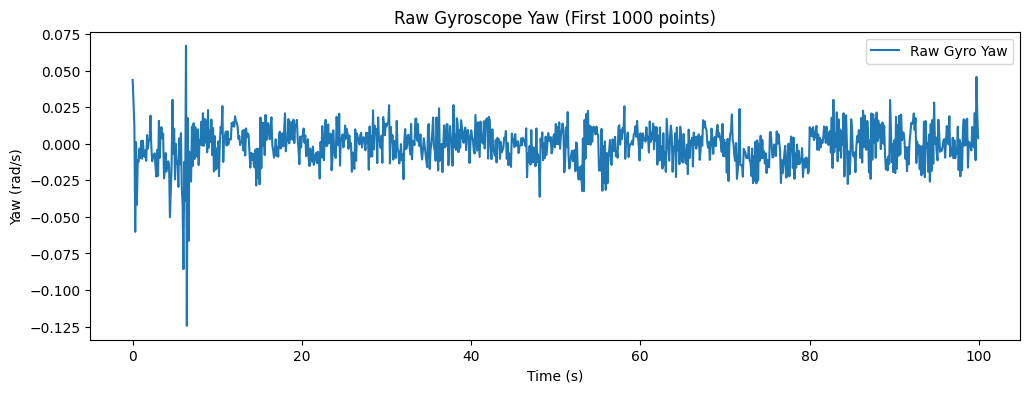

In [5]:
file_path = '/Users/hamza/SIH/IO-VNBD/Synchronised V abd S datasets/Categorised IOVNB Dataset/Vw (Driver E)/Vw01/S-Vw1.csv'

# Load data with latin-1 encoding
df = pd.read_csv(file_path, encoding='latin-1')
# Strip any leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Extract time (convert ms to seconds) and Gyroscope columns
time_sec = df['TIME SINCE START (ms)'] / 1000.0
gyro_yaw = df['GYROSCOPE Yaw (rad/s)']
gyro_pitch = df['GYROSCOPE Pitch (rad/s)']
gyro_roll = df['GYROSCOPE Roll (rad/s)']

# For hyperparameter tuning, we will use a subset of the data (e.g., first 1000 points) to speed up training
# ARIMA can be slow on very large datasets (~90k points)
subset_size = 1000
train_yaw = gyro_yaw.iloc[:subset_size]
time_subset = time_sec.iloc[:subset_size]

plt.figure(figsize=(12, 4))
plt.plot(time_subset, train_yaw, label='Raw Gyro Yaw')
plt.title('Raw Gyroscope Yaw (First 1000 points)')
plt.xlabel('Time (s)')
plt.ylabel('Yaw (rad/s)')
plt.legend()
plt.show()

### 2. Hyperparameter Tuning using Auto-ARIMA
We use `pmdarima.auto_arima` to search for the best `(p, d, q)` parameters. By default, you requested ARIMA(1,1,1) as a baseline, but `auto_arima` will verify if this is optimal by minimizing the AIC (Akaike Information Criterion) score.

In [14]:
print("Starting Auto-ARIMA tuning for Gyro Yaw...")

# Run auto_arima to find best hyperparameters
# We constrain d=1 to handle the drift/random walk nature of gyro bias
auto_model = pm.auto_arima(
    train_yaw, 
    start_p=0, start_q=0,
    max_p=1, max_q=1, 
    d=1,                # Enforce 1 level of differencing as requested
    seasonal=False,     # Gyro drift is generally non-seasonal over short periods
    trace=True,
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True
)

print("\nBest Model Summary:")
print(auto_model.summary())

Starting Auto-ARIMA tuning for Gyro Yaw...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-5082.151, Time=0.14 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-5810.638, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-5818.449, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-5084.146, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-5868.538, Time=0.10 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-5890.124, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-5820.428, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-5812.626, Time=0.02 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0]          
Total fit time: 0.622 seconds

Best Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:               SARIMAX(1, 1, 1)   Log Likelihood                2948.062
Date:                Fri, 04 Sep 2026   AIC

### 3. Fit the Baseline Model & Debias
Once the best parameters are found (or using the requested baseline ARIMA(1,1,1)), we fit the model to estimate the underlying bias (trend). We then subtract this trend from the raw signal.

Using ARIMA order: (1, 1, 1)


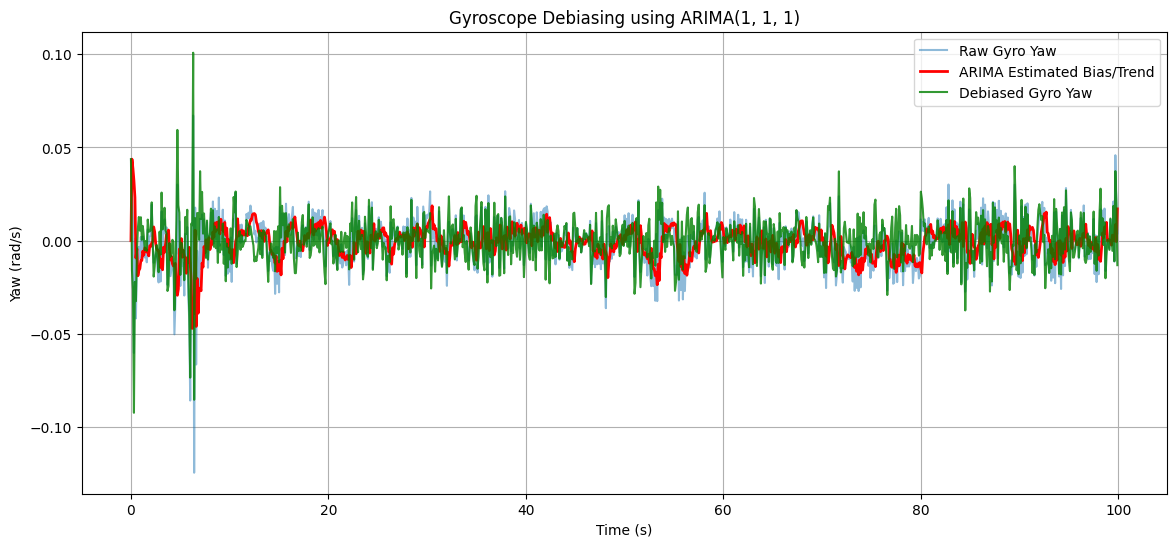

In [15]:
# Get the optimal parameters found (or force (1,1,1))
best_order = auto_model.order
print(f"Using ARIMA order: {best_order}")

# You can uncomment the line below to strictly force ARIMA(1,1,1) if tuning suggests otherwise
# best_order = (1, 1, 1)

# Fit statsmodels ARIMA
model = ARIMA(train_yaw, order=best_order)
fitted_model = model.fit()

# The 'fittedvalues' represent the model's estimate of the signal + bias at each step.
# To debias, we subtract the rolling estimated bias. 
# In differenced models, the predicted trend is often the fitted values.
estimated_bias = fitted_model.predict(typ='levels')

# Debiased Signal = Raw - Estimated Bias
debiased_yaw = train_yaw - estimated_bias

plt.figure(figsize=(14, 6))
plt.plot(time_subset, train_yaw, label='Raw Gyro Yaw', alpha=0.5)
plt.plot(time_subset, estimated_bias, label='ARIMA Estimated Bias/Trend', color='red', linewidth=2)
plt.plot(time_subset, debiased_yaw, label='Debiased Gyro Yaw', color='green', alpha=0.8)

plt.title(f'Gyroscope Debiasing using ARIMA{best_order}')
plt.xlabel('Time (s)')
plt.ylabel('Yaw (rad/s)')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
from sklearn.metrics import r2_score
# Calculate R-squared score
# True values = raw gyro signal, Predicted values = ARIMA estimated bias
r2 = r2_score(train_yaw, estimated_bias)
print(f"ARIMA R² Score: {r2:.4f}")

ARIMA R² Score: 0.0976


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.2/127.2 MB 11.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 11.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 16.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 17.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.0/100.0 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 15.7 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 65.5.0
    Uninstalling setuptools-65.5.0:
      Successfully uninstalled setuptools-65.5.0

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the

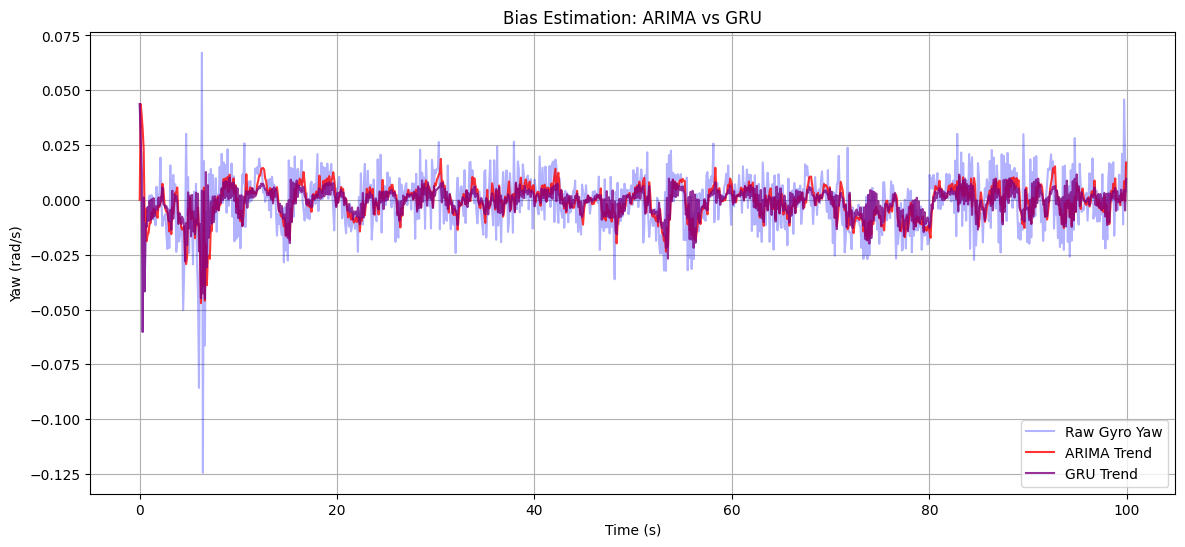

In [17]:
# 1. Install PyTorch
%pip install torch scikit-learn

import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 2. Prepare the sequence data for the GRU
# Neural networks train much better on scaled data
scaler = StandardScaler()
yaw_scaled = scaler.fit_transform(train_yaw.values.reshape(-1, 1))

seq_length = 10 # Look at the last 1 second (10 steps) to predict the next
X, y = [], []
for i in range(len(yaw_scaled) - seq_length):
    X.append(yaw_scaled[i : i + seq_length])
    y.append(yaw_scaled[i + seq_length])

X = torch.tensor(np.array(X), dtype=torch.float32)
y = torch.tensor(np.array(y), dtype=torch.float32)

# 3. Define a simple GRU Model
class GRUDebiaser(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1):
        super(GRUDebiaser, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.gru(x)
        # Take the output of the last time step
        return self.fc(out[:, -1, :])

gru_model = GRUDebiaser()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.01)

print("Training GRU...")
# 4. Train the Model
epochs = 75
for epoch in range(epochs):
    gru_model.train()
    optimizer.zero_grad()
    predictions = gru_model(X)
    loss = criterion(predictions, y)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 25 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# 5. Predict and Unscale
gru_model.eval()
with torch.no_grad():
    gru_pred_scaled = gru_model(X).numpy()

gru_estimated_bias_trimmed = scaler.inverse_transform(gru_pred_scaled).flatten()

# Pad the first 'seq_length' steps with the original data to align the lengths
gru_estimated_bias = np.concatenate([train_yaw.values[:seq_length], gru_estimated_bias_trimmed])
gru_debiased_yaw = train_yaw.values - gru_estimated_bias

# 6. Evaluate and Plot
gru_r2 = r2_score(train_yaw.values, gru_estimated_bias)
print(f"\n--- Comparison ---")
print(f"ARIMA R² Score: {r2_score(train_yaw, estimated_bias):.4f}")
print(f"GRU R² Score:   {gru_r2:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(time_subset, train_yaw.values, label='Raw Gyro Yaw', alpha=0.3, color='blue')

# Plot ARIMA trend in Red
plt.plot(time_subset, estimated_bias, label='ARIMA Trend', color='red', linewidth=1.5, alpha=0.8)

# Plot GRU trend in Purple
plt.plot(time_subset, gru_estimated_bias, label='GRU Trend', color='purple', linewidth=1.5, alpha=0.8)

plt.title('Bias Estimation: ARIMA vs GRU')
plt.xlabel('Time (s)')
plt.ylabel('Yaw (rad/s)')
plt.legend()
plt.grid(True)
plt.show()